In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.svm import LinearSVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [59]:
df = pd.read_csv("./Boston.csv")
eps=5
df

,town,tract,longitude,latitude,crime,residential,industrial,river,nox,rooms,older,distance,highway,tax,ptratio,lstat,cmedv
0,Nahant,2011,-70.955002,42.255001,0.00632,18.0,2.31,no,0.538,6.575,65.199997,4.0900,1,296,15.300000,4.98,24.000000
1,Swampscott,2021,-70.949997,42.287498,0.02731,0.0,7.07,no,0.469,6.421,78.900002,4.9671,2,242,17.799999,9.14,21.600000
2,Swampscott,2022,-70.935997,42.283001,0.02729,0.0,7.07,no,0.469,7.185,61.099998,4.9671,2,242,17.799999,4.03,34.700001
3,Marblehead,2031,-70.928001,42.292999,0.03237,0.0,2.18,no,0.458,6.998,45.799999,6.0622,3,222,18.700001,2.94,33.400002
4,Marblehead,2032,-70.921997,42.298000,0.06905,0.0,2.18,no,0.458,7.147,54.200001,6.0622,3,222,18.700001,5.33,36.200001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,Winthrop,1801,-70.986000,42.231201,0.06263,0.0,11.93,no,0.573,6.593,69.099998,2.4786,1,273,21.000000,9.67,22.400000
502,Winthrop,1802,-70.990997,42.227501,0.04527,0.0,11.93,no,0.573,6.120,76.699997,2.2875,1,273,21.000000,9.08,20.600000
503,Winthrop,1803,-70.994797,42.226002,0.06076,0.0,11.93,no,0.573,6.976,91.000000,2.1675,1,273,21.000000,5.64,23.900000
504,Winthrop,1804,-70.987503,42.223999,0.10959,0.0,11.93,no,0.573,6.794,89.300003,2.3889,1,273,21.000000,6.48,22.000000


In [60]:
len(df)

506

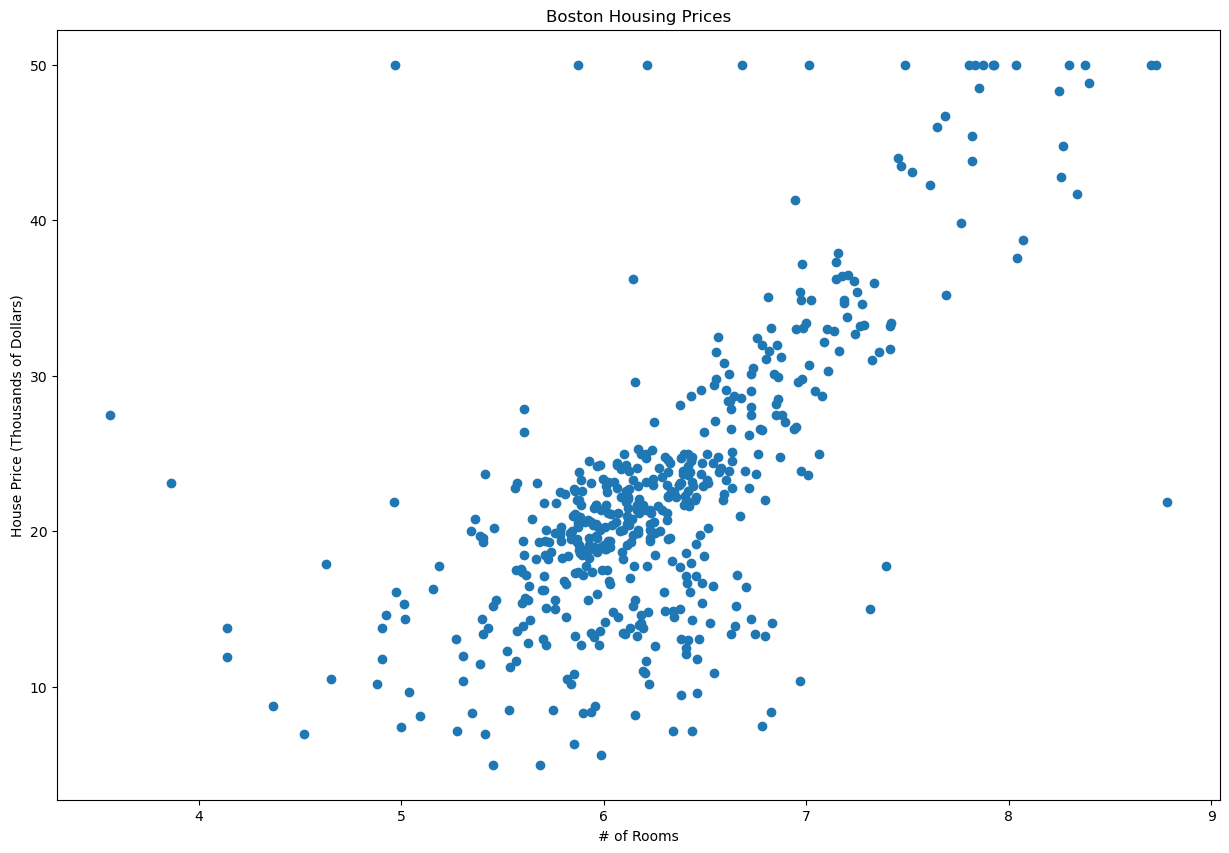

In [61]:
df_numeric = df.select_dtypes(include=['number'])

df_numeric.corr()
abs(df_numeric.corr())['cmedv'].sort_values(ascending=False)

plt.figure(figsize=(15,10))
plt.scatter(x=df['rooms'], y=df['cmedv'])
plt.xlabel('# of Rooms')
plt.ylabel('House Price (Thousands of Dollars)')
plt.title('Boston Housing Prices')
plt.show()

In [62]:
x = np.array(df["rooms"]).reshape(-1,1)
y = np.array(df["cmedv"]).reshape(-1,1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

y_train = y_train.reshape(len(y_train))
y_test = y_test.reshape(len(y_test))

In [63]:
lm = LinearRegression()

lm.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Intercept: -35.558
Coefficient: 9.232
MAE=$4,413.82


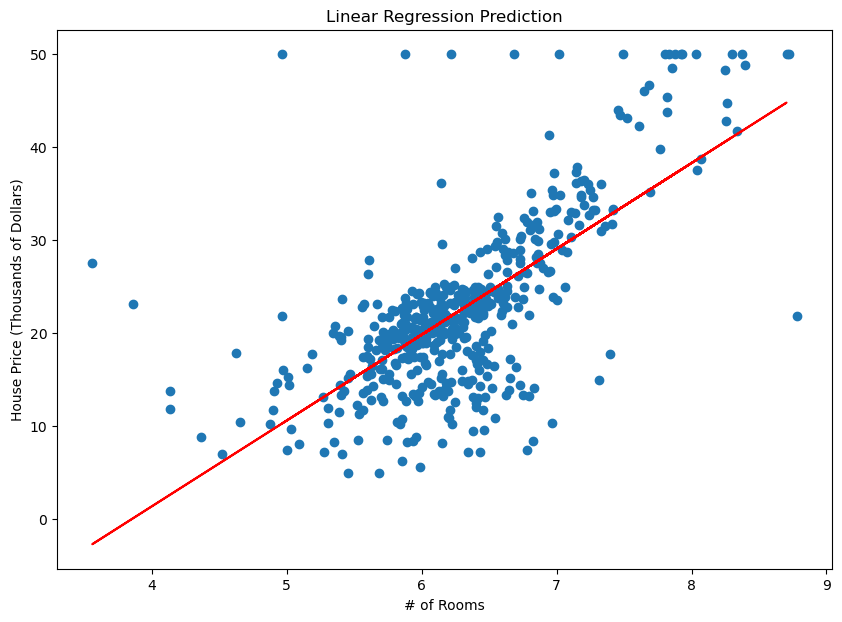

In [64]:
print("Intercept: {:,.3f}".format(lm.intercept_))
print("Coefficient: {:,.3f}".format(lm.coef_[0]))
mae = mean_absolute_error(y_test, lm.predict(x_test))
print("MAE=${:,.2f}".format(1000*mae))

plt.figure(figsize=(10,7))
plt.scatter(x=df['rooms'], y=df['cmedv'])
plt.plot(x_test, lm.predict(x_test), color='red')
plt.xlabel('# of Rooms')
plt.ylabel('House Price (Thousands of Dollars)')
plt.title('Linear Regression Prediction')
plt.show()

In [65]:
def svr_result(y_test, x_test, fitted_svr_model):
    print("C: {}".format(fitted_svr_model.C))
    print("Epsilon: {}".format(fitted_svr_model.epsilon))
    
    print("Intercept: {:,.3f}".format(fitted_svr_model.intercept_[0]))
    print("Coefficient: {:,.3f}".format(fitted_svr_model.coef_[0]))
    
    mae = mean_absolute_error(
        y_test,
        fitted_svr_model.predict(x_test)
    )
    print("MAE = ${:,.2f}".format(1000 * mae))
    
    perc_within_eps = (
        100 * np.sum(
            np.abs(y_test - fitted_svr_model.predict(x_test))
            < eps
        ) / len(y_test)
    )
    
    print("Percentage within Epsilon = {:.2f}%".format(perc_within_eps))
    plt.figure(figsize=(10,7))
    plt.scatter(x=df['rooms'], y=df['cmedv'])
    plt.plot(x_test, fitted_svr_model.predict(x_test), color='red')
    plt.plot(x_test, fitted_svr_model.predict(x_test)+eps, color='black')
    plt.plot(x_test, fitted_svr_model.predict(x_test)-eps, color='black')
    plt.xlabel('# of Rooms')
    plt.ylabel('House Price (Thousands of Dollars)')
    plt.title('SVR Prediction')
    plt.show()

In [66]:
eps = 5
svr = LinearSVR(epsilon=eps, C=0.01, fit_intercept=True)

svr.fit(x_train, y_train)

,epsilon,5
,tol,0.0001
,C,0.01
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,1000


C: 0.01
Epsilon: 5
Intercept: 0.370
Coefficient: 3.136
MAE = $5,783.35
Percentage within Epsilon = 57.84%


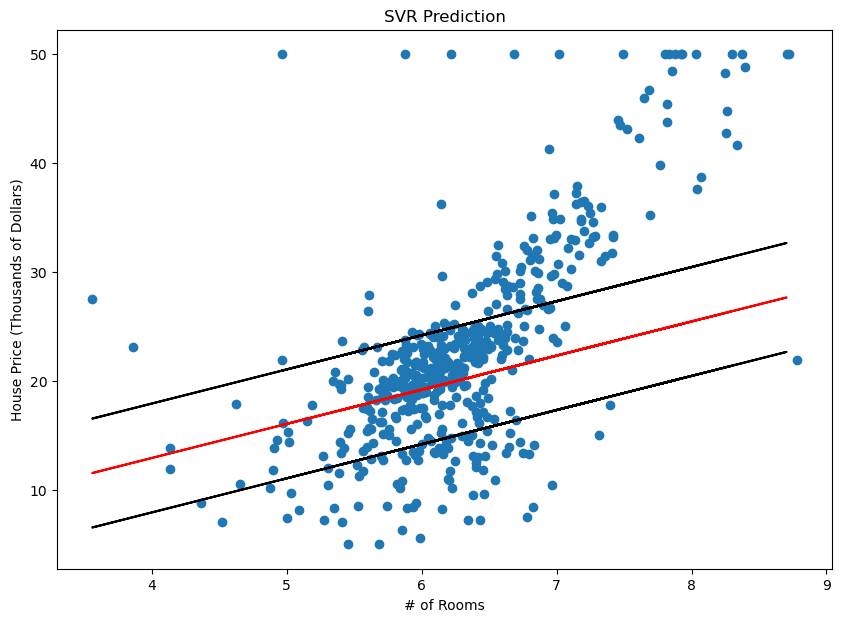

In [67]:
svr_result(y_test, x_test, svr)

In [68]:
eps = 5
svr_high_C = LinearSVR(epsilon=eps, C=1, fit_intercept=True)

svr_high_C.fit(x_train, y_train)

,epsilon,5
,tol,0.0001
,C,1
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,1000


C: 1
Epsilon: 5
Intercept: -10.059
Coefficient: 5.151
MAE = $4,826.81
Percentage within Epsilon = 63.73%


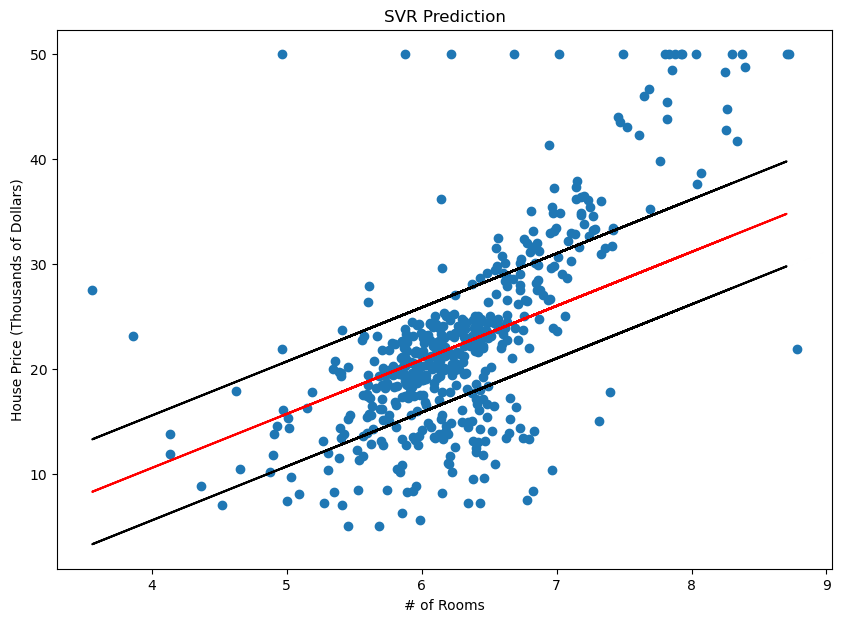

In [69]:
svr_result(y_test, x_test, svr_high_C)

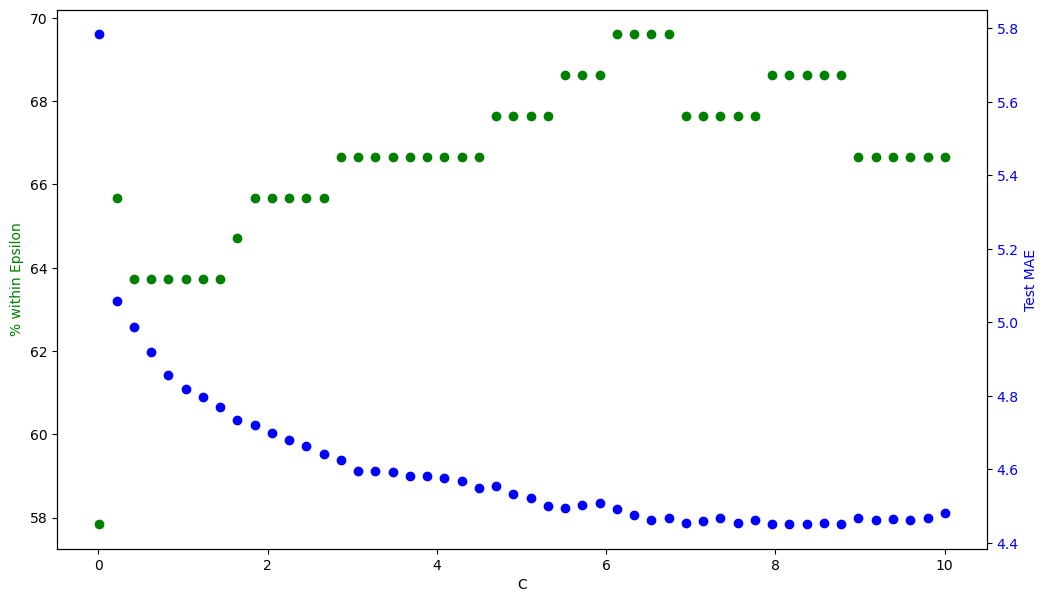

In [70]:
test_mae_list = []
perc_within_epS_list = []

eps = 5
c_space = np.linspace(0.01, 10)

for c in c_space :
    varied_svr = LinearSVR(epsilon=eps, C=c, fit_intercept=True, max_iter=10000)
    
    varied_svr.fit(x_train, y_train)
    
    test_mae = mean_absolute_error(y_test, varied_svr.predict(x_test))
    test_mae_list.append(test_mae)
    
    perc_within_eps = 100 * np.sum(abs(y_test-varied_svr.predict(x_test)) <= eps) / len(y_test)
    perc_within_epS_list.append(perc_within_eps)

fig, ax1 = plt.subplots(figsize=(12,7))

color='green'

ax1.set_xlabel('C')
ax1.set_ylabel('% within Epsilon', color=color)
ax1.scatter(c_space, perc_within_epS_list, color=color)

color='blue'

ax2 = ax1.twinx()
ax2.set_ylabel('Test MAE', color=color)
ax2.scatter(c_space, test_mae_list, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.show()

In [71]:
m = max(perc_within_epS_list)
inds = [i for i, j in enumerate(perc_within_epS_list) if j == m]
C = c_space[inds[0]]
print("best C=", C)

best C= 6.1263265306122445


C: 6.1263265306122445
Epsilon: 5
Intercept: -27.751
Coefficient: 7.960
MAE = $4,492.07
Percentage within Epsilon = 68.63%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


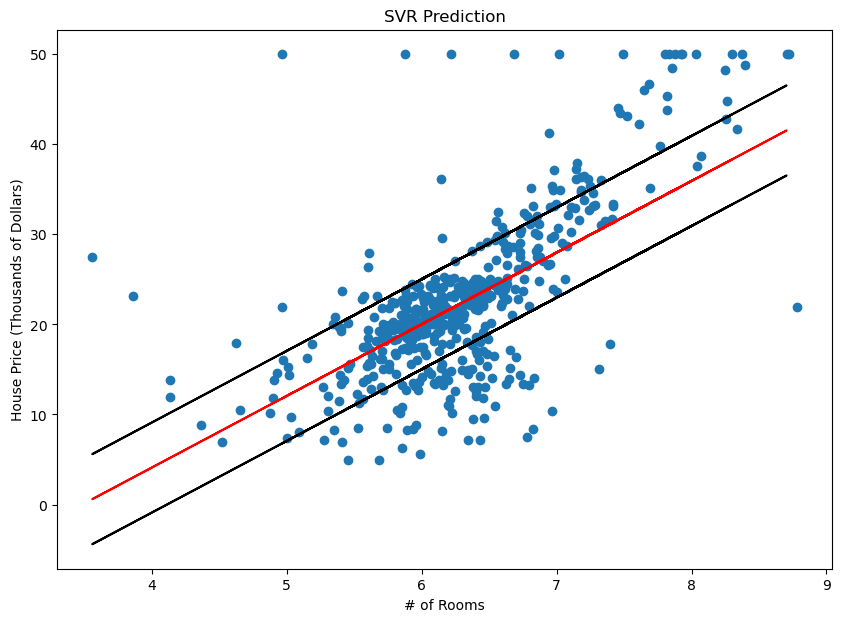

In [72]:
eps = 5
svr_best_C = LinearSVR(epsilon=eps, C=C, fit_intercept=True)

svr_best_C.fit(x_train, y_train)
svr_result(y_test, x_test, svr_best_C)

In [73]:
grid = {
    'C':np.linspace(0.01, 10),
    'epsilon': np.linspace(0.01, 10)
}

svr_gridsearch = LinearSVR(fit_intercept=True, max_iter=10000)

In [74]:
grid_svr = GridSearchCV(svr_gridsearch, grid, scoring="neg_mean_absolute_error", cv=5)

grid_svr.fit(x_train, y_train)

,estimator,LinearSVR(max_iter=10000)
,param_grid,"{'C': array([ 0.01 ... 10. ]), 'epsilon': array([ 0.01 ... 10. ])}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,epsilon,np.float64(0....5510204081634)


In [75]:
best_grid_svr_mae = grid_svr.best_estimator_
best_grid_svr_mae.fit(x_train, y_train) 

,epsilon,np.float64(0....5510204081634)
,tol,0.0001
,C,np.float64(10.0)
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,10000


C: 10.0
Epsilon: 0.41775510204081634
Intercept: -34.208
Coefficient: 9.053
MAE = $4,411.94
Percentage within Epsilon = 69.61%


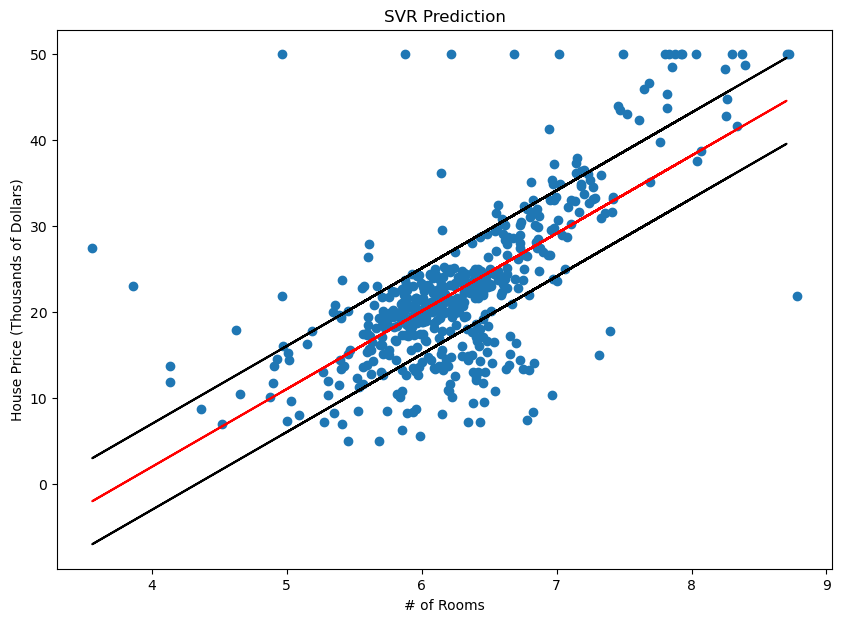

In [76]:
svr_result(y_test, x_test, best_grid_svr_mae)

In [77]:
def frac_within_eps(y_true, y_pred):
    return np.sum(abs(y_true-y_pred) <=eps) / len(y_true)

my_scorer = make_scorer(frac_within_eps, greater_is_better=True)

grid_svr_eps = GridSearchCV(svr_gridsearch, grid, scoring=my_scorer, cv=5)
grid_svr_eps.fit(x_train, y_train)

,estimator,LinearSVR(max_iter=10000)
,param_grid,"{'C': array([ 0.01 ... 10. ]), 'epsilon': array([ 0.01 ... 10. ])}"
,scoring,make_scorer(f...hod='predict')
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,epsilon,np.float64(0....7755102040817)


In [78]:
best_grid_svr_eps = grid_svr_eps.best_estimator_
best_grid_svr_eps.fit(x_train, y_train)

,epsilon,np.float64(0....7755102040817)
,tol,0.0001
,C,np.float64(7.145714285714286)
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,10000


C: 7.145714285714286
Epsilon: 0.21387755102040817
Intercept: -32.273
Coefficient: 8.733
MAE = $4,418.62
Percentage within Epsilon = 70.59%


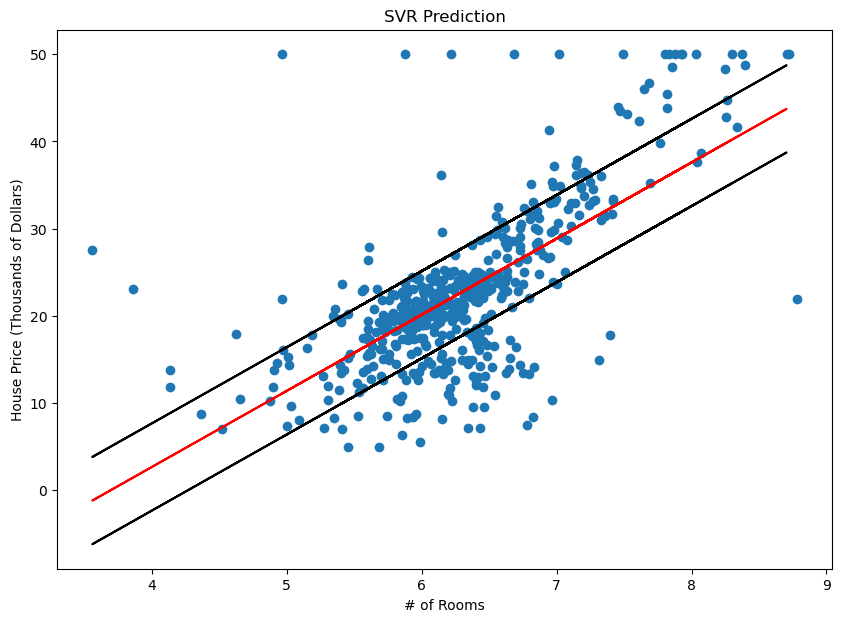

In [79]:
svr_result(y_test, x_test, best_grid_svr_eps)